# Super-Resolution Demo

Two sections:
1. **Data pipeline** — visualize how LR images are generated from HR, at scales ×2 / ×4 / ×8
2. **Model inference** — run a trained checkpoint and compare LR input vs SR output

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/and-petukhov/studies/efml-unet


## 1. Data Pipeline: Expected Input vs Output

The model receives a bicubic-upsampled LR image (same spatial size as HR) and must reconstruct the sharp HR.  
Change `SCALE` below to see how much information is lost at each downsampling factor.

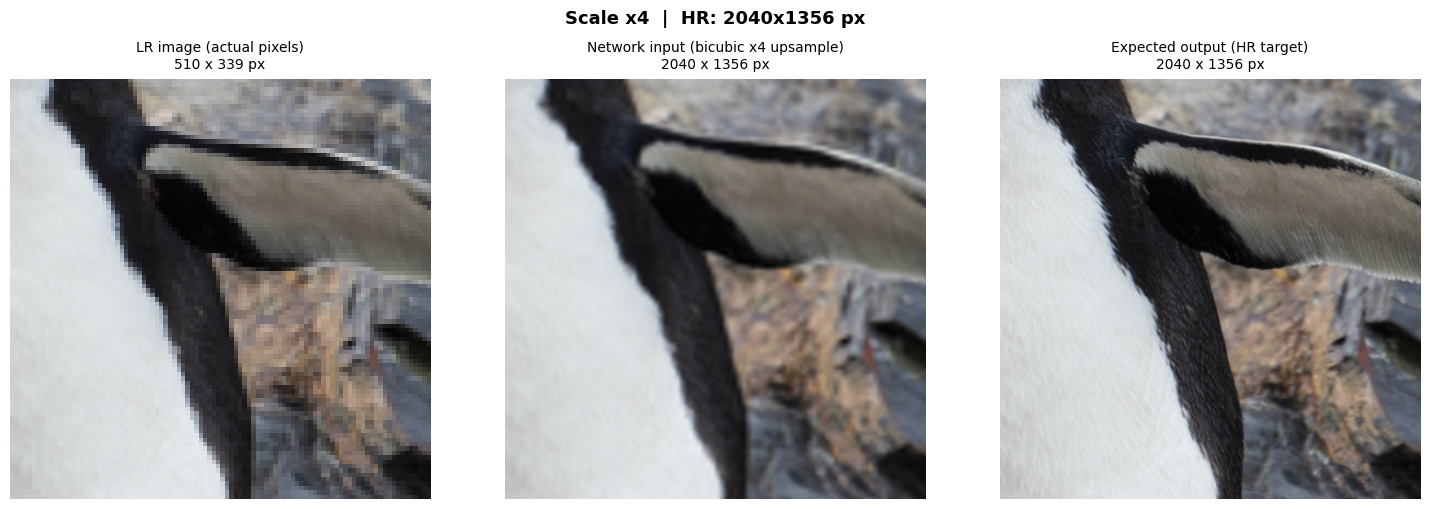

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

# ─── Change me ───────────────────────────────────────────────────
SCALE = 4          # try 2, 4, or 8
IMAGE  = '0801.png'  # any file from data/sr/val_hr/
CROP   = 384       # display crop size (pixels, from center of HR image)
# ─────────────────────────────────────────────────────────────────

hr = Image.open(PROJECT_ROOT / 'data' / 'sr' / 'val_hr' / IMAGE).convert('RGB')

lr_small  = hr.resize((hr.width // SCALE, hr.height // SCALE), Image.BICUBIC)
lr_input  = lr_small.resize(hr.size, Image.BICUBIC)  # what the model actually receives

def center_crop(img, w, h):
    cx, cy = img.width // 2, img.height // 2
    return img.crop((cx - w // 2, cy - h // 2, cx + w // 2, cy + h // 2))

# Crop corresponding regions at each resolution
lr_display  = center_crop(lr_small, CROP // SCALE, CROP // SCALE)
net_display = center_crop(lr_input, CROP, CROP)
hr_display  = center_crop(hr, CROP, CROP)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Scale x{SCALE}  |  HR: {hr.width}x{hr.height} px',
    fontsize=13,
    fontweight='bold',
    y=1.01)

panels = [
    (lr_display,  f'LR image (actual pixels)\n{lr_small.width} x {lr_small.height} px',  'nearest'),
    (net_display, f'Network input (bicubic x{SCALE} upsample)\n{lr_input.width} x {lr_input.height} px', 'bilinear'),
    (hr_display,  f'Expected output (HR target)\n{hr.width} x {hr.height} px',            'bilinear'),
]

for ax, (img, title, interp) in zip(axes, panels):
    ax.imshow(img, interpolation=interp)
    ax.set_title(title, fontsize=10, pad=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Model Inference

Load a trained checkpoint and run it on a val image.

In [4]:
import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf

# ─── Change me ───────────────────────────────────────────────────
CHECKPOINT  = 'srunet_x4_800pics.pt'  # sr_unet_x3.pt / sr_unet_x4.pt / sr_unet_x8.pt
INFER_SCALE = 4                 # must match the checkpoint
# ─────────────────────────────────────────────────────────────────

cfg_dir = PROJECT_ROOT / 'src' / 'configs'

# Load configs via OmegaConf (no Hydra singleton — safe to re-run cells)
config = OmegaConf.merge(
    OmegaConf.load(cfg_dir / f'baseline_x{INFER_SCALE}.yaml'),
    {'model': OmegaConf.load(cfg_dir / 'model' / 'unet.yaml')},
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = instantiate(config.model).to(device)  # uses _target_ from unet.yaml
state = torch.load(PROJECT_ROOT / 'checkpoints' / CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(state['model_state_dict'])
model.eval()

print(f'Loaded {CHECKPOINT} on {device}')
print(f'Params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M')

Loaded srunet_x4_800pics.pt on cuda
Params: 17.3M


In [5]:
from torchvision.transforms import functional as TF

# ─── Change me ───────────────────────────────────────────────────
INFER_IMAGE = '0801.png'
# ─────────────────────────────────────────────────────────────────

hr = Image.open(PROJECT_ROOT / 'data' / 'sr' / 'val_hr' / INFER_IMAGE).convert('RGB')
lr_small = hr.resize((hr.width // INFER_SCALE, hr.height // INFER_SCALE), Image.BICUBIC)
lr_input = lr_small.resize(hr.size, Image.BICUBIC)

lr_tensor = TF.to_tensor(lr_input).unsqueeze(0).to(device)
with torch.no_grad():
    sr_tensor = model(lr_tensor).clamp(0.0, 1.0)

sr_img = TF.to_pil_image(sr_tensor.squeeze(0).cpu())
print(f'Input:  {lr_input.width}x{lr_input.height} (bicubic-upsampled LR)')
print(f'Output: {sr_img.width}x{sr_img.height}')

Input:  2040x1356 (bicubic-upsampled LR)
Output: 2040x1356


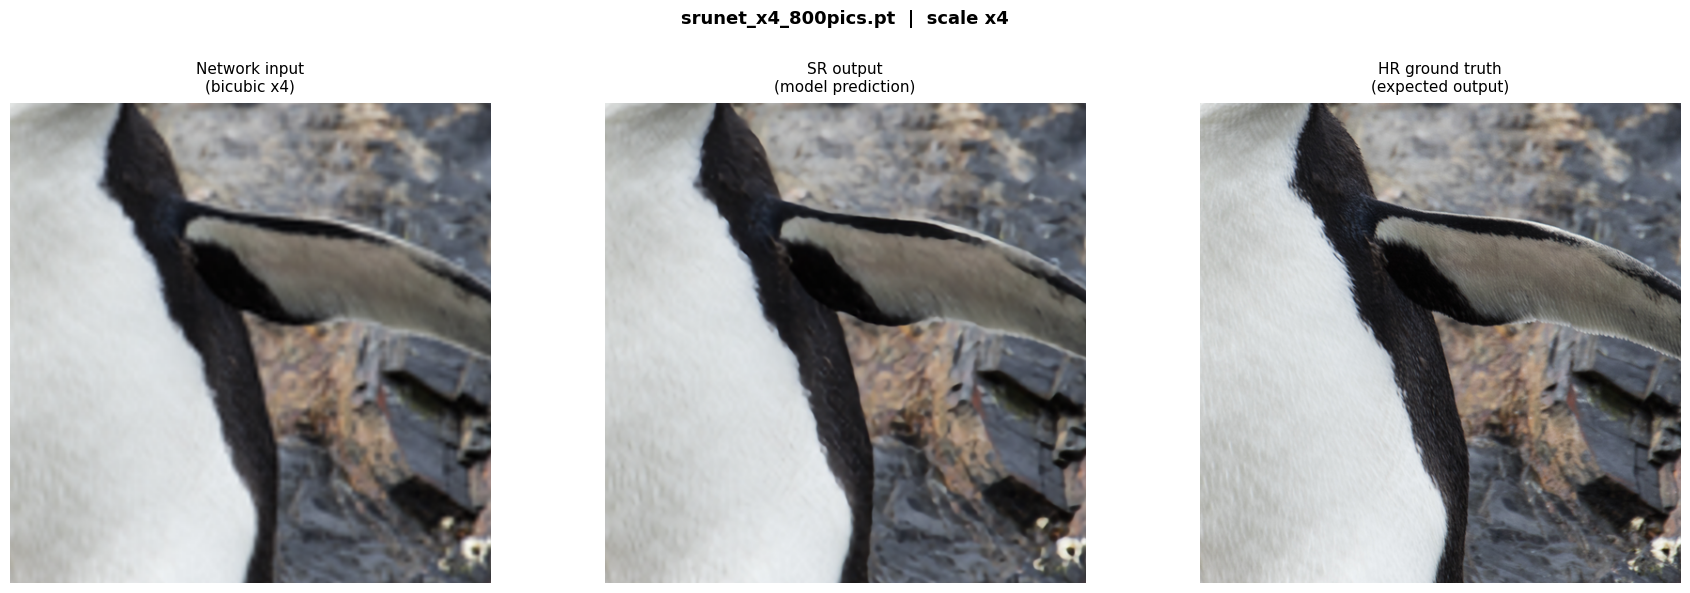

In [7]:
CROP = 512

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'{CHECKPOINT}  |  scale x{INFER_SCALE}',
    fontsize=13,
    fontweight='bold',
    y=0.98
)

panels = [
    (center_crop(lr_input, CROP, CROP), f'Network input\n(bicubic x{INFER_SCALE})'),
    (center_crop(sr_img,   CROP, CROP), 'SR output\n(model prediction)'),
    (center_crop(hr,       CROP, CROP), 'HR ground truth\n(expected output)'),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()